[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mlnjsh/Introduction-to-Deep-Learning/blob/main/notebooks_DeepLearning/04_early_stopping_keras.ipynb)

# 04. Early Stopping — Keras

Training too long overfits: train loss keeps dropping while test loss turns back up. **Early stopping** watches the validation loss and halts when it stops improving, optionally restoring the best weights.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

---

## 1. Setup & imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
keras.utils.set_random_seed(42)          # reproducible weights + shuffling
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.14.0


## 2. Load the data

In [2]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

The features are already scaled to `[0,1]`, so we only drop the ID and split. We use a **stratified** split so the approval rate matches in train and test.

In [3]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [4]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test/val (dashed) loss and accuracy over epochs."""
    h = hist.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["loss"], label="train")
    ax[0].plot(h["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["accuracy"], label="train")
    ax[1].plot(h["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. First, train too long (no early stopping)

We deliberately use a larger network and many epochs to *provoke* overfitting.

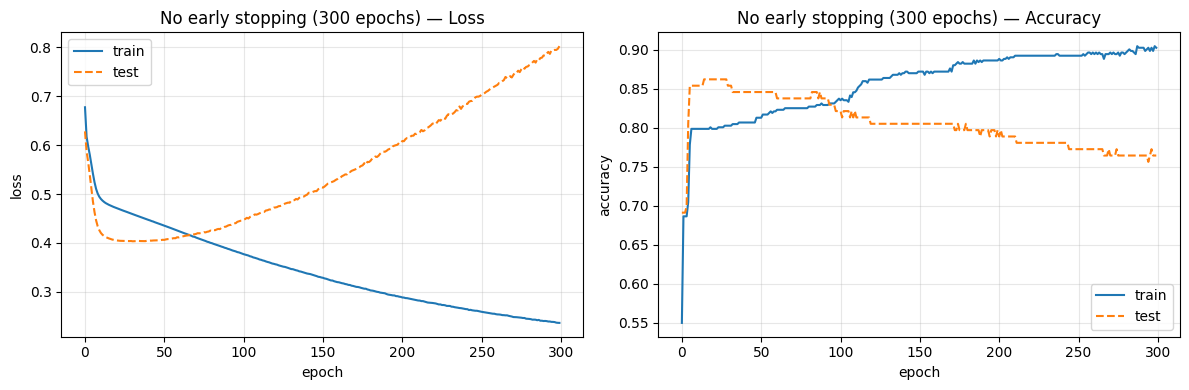

Best test loss was at epoch 30, but we trained to 300.


In [5]:
def build_big():
    keras.utils.set_random_seed(42)
    model = keras.Sequential([
        keras.Input(shape=(N_FEATURES,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1,  activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

hist_no_es = build_big().fit(X_train, y_train, validation_data=(X_test, y_test),
                             epochs=300, batch_size=32, verbose=0)
plot_history(hist_no_es, "No early stopping (300 epochs)")
best_epoch = int(np.argmin(hist_no_es.history["val_loss"]))
print("Best test loss was at epoch %d, but we trained to 300." % best_epoch)

## 5. Now with EarlyStopping

`patience=15` → stop if test loss hasn't improved for 15 epochs. `restore_best_weights=True` → roll back to the best epoch, not the last.

Epoch 46: early stopping


Restoring model weights from the end of the best epoch: 31.


Stopped after 46 epochs (out of 300).


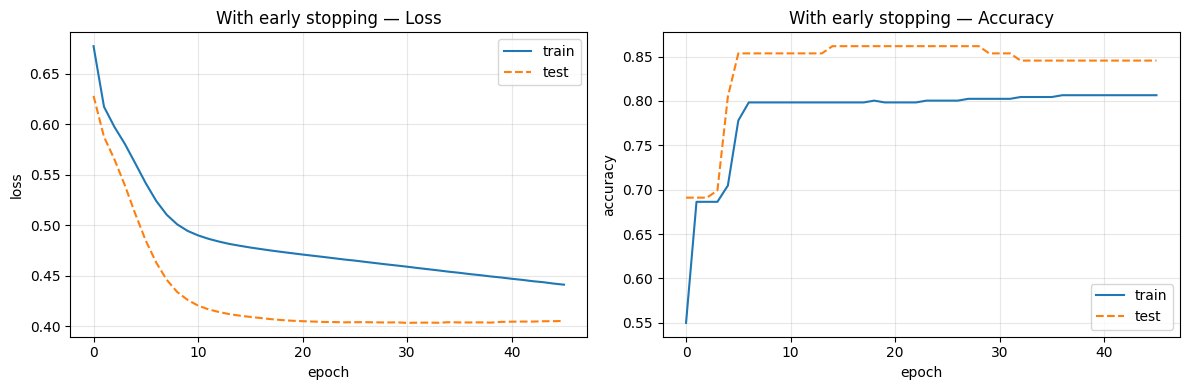

In [6]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True, verbose=1,
)
hist_es = build_big().fit(X_train, y_train, validation_data=(X_test, y_test),
                          epochs=300, batch_size=32, callbacks=[early_stop], verbose=0)
print("Stopped after %d epochs (out of 300)." % len(hist_es.history["loss"]))
plot_history(hist_es, "With early stopping")

## 6. Side by side

In [7]:
print("Without ES:  test loss = %.4f | test acc = %.4f  (300 epochs)" %
      (hist_no_es.history["val_loss"][-1], hist_no_es.history["val_accuracy"][-1]))
print("With ES:     test loss = %.4f | test acc = %.4f  (%d epochs, best restored)" %
      (min(hist_es.history["val_loss"]), max(hist_es.history["val_accuracy"]),
       len(hist_es.history["loss"])))

Without ES:  test loss = 0.8020 | test acc = 0.7642  (300 epochs)
With ES:     test loss = 0.4034 | test acc = 0.8618  (46 epochs, best restored)


## Takeaways
- Without early stopping the test loss curve **U-turns** — the model memorises the training set.
- Early stopping is essentially free regularization: it costs nothing and prevents wasted epochs.
- `restore_best_weights=True` is important — otherwise you keep the *last* (already-overfit) weights, not the best.
- `patience` trades off: too small stops prematurely on noise; too large wastes epochs.
- **Next:** `05_grad_clipping_keras` — keeping gradients from exploding.